In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

df = pd.read_csv("/content/Churn_Modelling.csv")
print(df.shape)
print("Nulls:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df.CustomerId.duplicated().sum())
df.head()

(10000, 14)
Nulls: 0
Duplicate rows: 0
Duplicate customer IDs: 0


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df = df.drop(columns=["RowNumber", "Surname"])

df["Geography"] = df["Geography"].str.strip().str.title()
df["Gender"] = df["Gender"].str.strip().str.title()

df["tenure_band"] = pd.cut(df.Tenure, [-1, 2, 5, 8, 10], labels=["0-2", "3-5", "6-8", "9-10"])
df["age_group"] = pd.cut(df.Age, [0, 29, 39, 49, 59, 100], labels=["<30", "30-39", "40-49", "50-59", "60+"])
df["zero_balance"] = df.Balance.eq(0)

df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,tenure_band,age_group,zero_balance
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0-2,40-49,True
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0-2,40-49,False
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,6-8,40-49,False
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0-2,30-39,True
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0-2,40-49,False


In [ ]:
print("Overall churn %:", round(df.Exited.mean() * 100, 1))

for col in ["Geography", "tenure_band", "age_group", "NumOfProducts", "IsActiveMember"]:
    print(df.groupby(col, observed=True).Exited.agg(["count", "mean"]).round(3), "\n")

Overall churn %: 20.4
           count   mean
Geography              
France      5014  0.162
Germany     2509  0.324
Spain       2477  0.167 

             count   mean
tenure_band              
0-2           2496  0.212
3-5           3010  0.208
6-8           3020  0.189
9-10          1474  0.213 

           count   mean
age_group              
<30         1641  0.076
30-39       4346  0.109
40-49       2618  0.308
50-59        869  0.560
60+          526  0.279 

               count   mean
NumOfProducts              
1               5084  0.277
2               4590  0.076
3                266  0.827
4                 60  1.000 

                count   mean
IsActiveMember              
0                4849  0.269
1                5151  0.143 



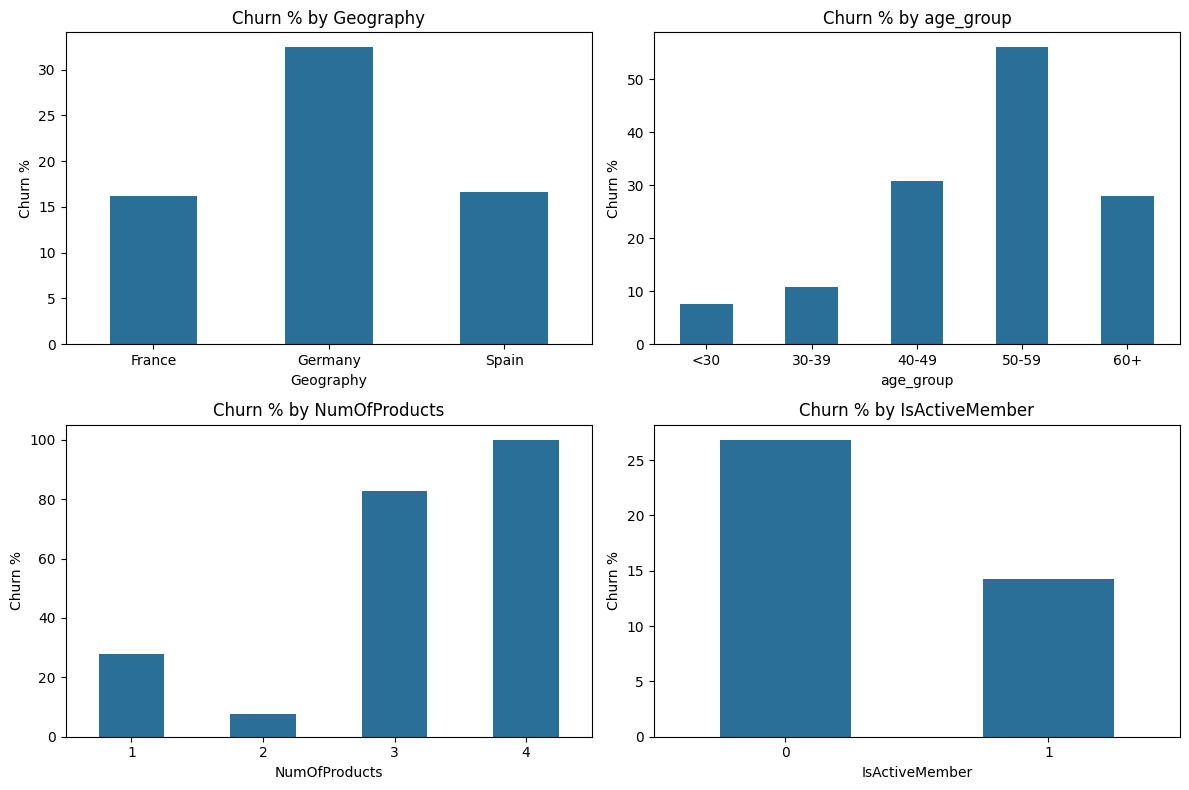

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for a, col in zip(ax.flat, ["Geography", "age_group", "NumOfProducts", "IsActiveMember"]):
    (df.groupby(col, observed=True).Exited.mean() * 100).plot.bar(ax=a, color="#2a6f97")
    a.set_title(f"Churn % by {col}")
    a.set_ylabel("Churn %")
    a.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("churn_by_segment.png", dpi=150)
plt.show()

In [ ]:
score = (np.where(df.Age >= 45, 2, np.where(df.Age >= 35, 1, 0))
       + np.where(df.NumOfProducts.isin([3, 4]), 3, np.where(df.NumOfProducts == 1, 1, 0))
       + (df.IsActiveMember == 0).astype(int)
       + (df.Geography == "Germany").astype(int))

df["risk_score"] = score
df["risk_tier"] = np.where(score >= 4, "High", np.where(score >= 2, "Medium", "Low"))

print(df.groupby("risk_tier").Exited.agg(["count", "sum", "mean"]).round(3))

           count   sum   mean
risk_tier                    
High        1518  1031  0.679
Low         3048   109  0.036
Medium      5434   897  0.165


In [ ]:
print(df.groupby("risk_score").Exited.agg(["count", "mean"]).round(3))

            count   mean
risk_score              
0             759  0.025
1            2289  0.039
2            3228  0.105
3            2206  0.253
4            1031  0.581
5             361  0.853
6              93  0.978
7              33  1.000


In [ ]:
inactive = df[df.IsActiveMember == 0]
n_in = len(inactive)                    # 4849
r_in = inactive.Exited.mean()           # 0.2685
total_churned = df.Exited.sum()         # 2037

# Scenario A: retention campaign se inactive churn 12% (relative) girta hai
new_rate = r_in * 0.88
saved = n_in * (r_in - new_rate)

print("Inactive churn:", round(r_in * 100, 1), "% ->", round(new_rate * 100, 1), "%")
print("Customers retained:", round(saved))
print("Overall churn:", round(df.Exited.mean() * 100, 1), "% ->",
      round((total_churned - saved) / len(df) * 100, 1), "%")

Inactive churn: 26.9 % -> 23.6 %
Customers retained: 156
Overall churn: 20.4 % -> 18.8 %


In [ ]:
r_act = df[df.IsActiveMember == 1].Exited.mean()     # 0.1427
reactivated = n_in * 0.25                            # 25% inactive ko active banao
saved_b = reactivated * (r_in - r_act)
new_inactive_rate = (inactive.Exited.sum() - saved_b) / n_in

print("Active churn:", round(r_act * 100, 1), "%")
print("Retained:", round(saved_b))
print("Inactive churn:", round(r_in * 100, 1), "% ->", round(new_inactive_rate * 100, 1), "%")
print("Relative reduction:", round((1 - new_inactive_rate / r_in) * 100, 1), "%")

Active churn: 14.3 %
Retained: 153
Inactive churn: 26.9 % -> 23.7 %
Relative reduction: 11.7 %


In [ ]:
for pct in [0.10, 0.25, 0.50]:
    s = n_in * pct * (r_in - r_act)
    nr = (inactive.Exited.sum() - s) / n_in
    print(f"{int(pct*100)}% reactivated -> inactive churn {round(nr*100,1)}%  (reduction {round((1-nr/r_in)*100,1)}%)")

10% reactivated -> inactive churn 25.6%  (reduction 4.7%)
25% reactivated -> inactive churn 23.7%  (reduction 11.7%)
50% reactivated -> inactive churn 20.6%  (reduction 23.4%)


In [ ]:
df.to_csv("churn_for_powerbi.csv", index=False)
print(df.shape)

(10000, 17)
